<a href="https://colab.research.google.com/github/GrizzlyToast/ML_Practise/blob/main/PainPlus_Dataset_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset Preprocessing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_json('/content/processed_posts.json')
df.drop(columns=['created_timestamp', 'score', 'upvote_ratio', 'post_id', 'image_url', 'comment_count'], inplace=True)
df.head()

FileNotFoundError: File /content/processed_posts.json does not exist

In [ ]:
def extract_op_comments(comments, author, comment_list) -> list[str]:
    if isinstance(comments, list):
        for comment in comments:
            if isinstance(comment, dict):
                if comment.get('author') == author:
                    comment_list.append(comment.get('text', ''))
                extract_op_comments(comment.get('replies', []), author, comment_list)
    return comment_list

def flatten_comments(row) -> pd.Series:
  if isinstance(row.get('comments'), list) and isinstance(row.get('author'), str):
    op = row['author']
    op_comments = []
    extract_op_comments(row['comments'], op, op_comments)
    return pd.Series({'op_comments': op_comments})
  return pd.Series({'op_comments': []})

df['op_comments'] = df.apply(flatten_comments, axis=1)['op_comments']
df.head()

In [ ]:
### Test: extract_op_comments() ###
import json
with open('/content/processed_posts.json') as f:
    posts = json.load(f)

row = posts[3]  # Dddnutzz post
op = row['author']  # "Dddnutzz"
op_comments = []
extract_op_comments(row['comments'], op, op_comments)
# Expected: 8 comments, including the depth-2 nested reply
print(len(op_comments))  # Should be 8

In [ ]:
df.drop(columns=['comments'])
df = df[['title', 'author', 'content', 'op_comments', 'survey_results']]
df.head()

In [ ]:
def flatten_survey_results(row) -> pd.Series:
  if isinstance(row.get('survey_results'), dict) :
    sr = row['survey_results']
    return pd.Series(
        {'clinically_diagnosed': sr['historical_information']['clinically_diagnosed'],
         'care_utilization_recent': sr['historical_information']['care_utilization_recent'],
         'treatments_tried': sr['historical_information']['treatments_tried'],
         'medication_safety_risk': sr['historical_information']['medication_safety_risk'],

         'body_regions': sr['pain_location']['body_regions'],
         'pain_intensity_0_10': sr['pain_location']['pain_intensity_0_10'],
         'pain_qualities': sr['pain_location']['pain_qualities'],
         'top_aggravators': sr['pain_location']['top_aggravators'],
         'top_relievers': sr['pain_location']['top_relievers'],

         'red_flag_present': sr['functional_physical_impairment']['red_flag_present'],
         'adl_limitation_level': sr['functional_physical_impairment']['adl_limitation_level'],
         'intolerable_activities': sr['functional_physical_impairment']['intolerable_activities'],

         'mood_anxiety_severity': sr['functional_emotional_impairment']['mood_anxiety_severity'],
         'suicidality_risk': sr['functional_emotional_impairment']['suicidality_risk'],
         'psychosocial_impact': sr['functional_emotional_impairment']['psychosocial_impact'],

         'sleep_problem_severity': sr['lifestyle_factors']['sleep_problem_severity'],
         'substance_abuse_risk': sr['lifestyle_factors']['substance_abuse_risk'],
         'employment_status': sr['lifestyle_factors']['employment_status'],
         'financial_strain': sr['lifestyle_factors']['financial_strain'],

         'chronic_pain': sr['chronic_pain']
         })
  return pd.Series({
      'clinically_diagnosed': None, 'care_utilization_recent': None, 'treatments_tried': None,
      'medication_safety_risk': None, 'body_regions': None, 'pain_intensity_0_10': None, 'pain_qualities': None,
      'top_aggravators': None, 'top_relievers': None, 'red_flag_present': None, 'adl_limitation_level': None, 'intolerable_activities': None,
      'mood_anxiety_severity': None, 'suicidality_risk': None, 'psychosocial_impact': None, 'sleep_problem_severity': None, 'substance_abuse_risk': None,
      'employment_status': None, 'financial_strain': None, 'chronic_pain': None
  })

df_processed = pd.concat([
    df[['title', 'author','content','op_comments']],
    df.apply(flatten_survey_results, axis=1)
    ], axis=1)
df_processed.head()

In [ ]:
df_exploded_pain_qualities = df_processed.explode('pain_qualities')
sns.barplot(x='pain_qualities', y='pain_intensity_0_10', data=df_exploded_pain_qualities)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_processed.to_csv('chronic_pain_dataset.csv', index=False)
#df_processed.to_json('train.json', index=False)

## Data Augmentation

https://arxiv.org/html/2505.13518v1#S1


https://arxiv.org/abs/2505.13518


In [1]:
from datasets import load_dataset
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df_processed = pd.read_csv("chronic_pain_dataset.csv")
df_processed.shape

(997, 24)

### Data Reduction

In [48]:
# Combine comment list
df_processed['temp_list_str'] = df_processed['op_comments'].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else ""
)
# Merge content with comments
df_processed['content'] = df_processed['content'] + " " + df_processed['temp_list_str']
df_processed.drop(columns=['temp_list_str', 'op_comments'], inplace=True)
df_processed.shape

(997, 23)

The op_comments column was merged into content to reduce feature complexity.

<Axes: xlabel='clinically_diagnosed', ylabel='Count'>

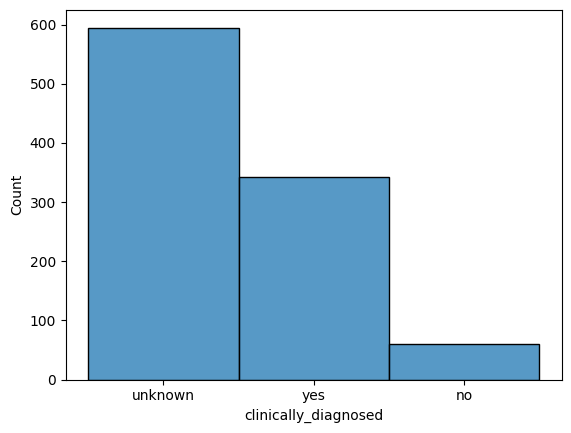

In [ ]:
sns.histplot(x="clinically_diagnosed", data = df_processed)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'unknown'),
  Text(1, 0, 'working_full_time'),
  Text(2, 0, 'disability_permanent'),
  Text(3, 0, 'unemployed'),
  Text(4, 0, 'student_full_time'),
  Text(5, 0, 'working_part_time'),
  Text(6, 0, 'other'),
  Text(7, 0, 'sick_leave'),
  Text(8, 0, 'disability_temporary'),
  Text(9, 0, 'homemaker'),
  Text(10, 0, 'retired')])

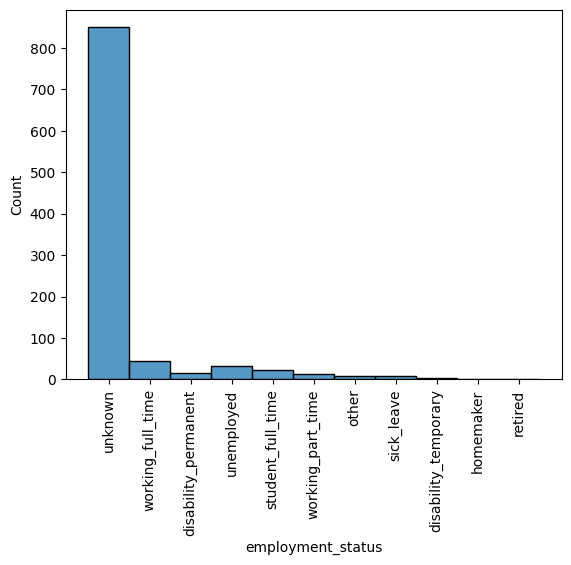

In [ ]:
sns.histplot(x="employment_status", data = df_processed)
plt.xticks(rotation=90)

<Axes: xlabel='pain_intensity_0_10', ylabel='Count'>

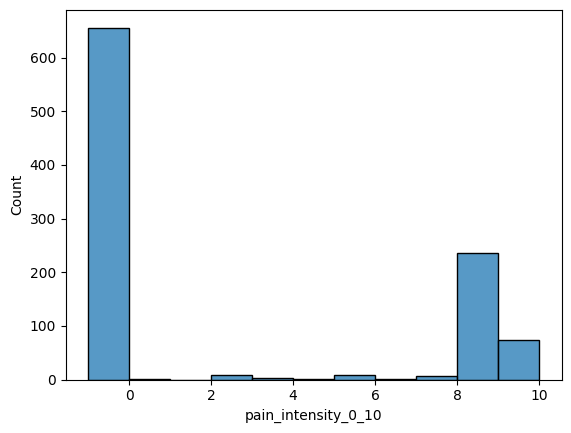

In [ ]:
sns.histplot(x="pain_intensity_0_10", data=df_processed)

/tmp/ipython-input-3025633131.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pie_data = [df_processed['chronic_pain'].value_counts().get(0,0), df_processed['chronic_pain'].value_counts().get(1,0)]


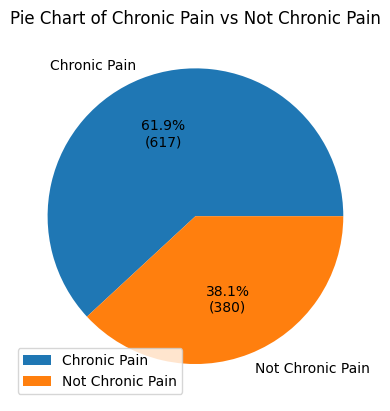

In [ ]:
def autopct_format(values):
  def my_format(pct):
    total = sum(values)
    val = int(round(pct*total/100.0))
    return '{:.1f}%\n({v:d})'.format(pct, v=val)
  return my_format
pie_data = [df_processed['chronic_pain'].value_counts().get(0,0), df_processed['chronic_pain'].value_counts().get(1,0)]
plt.pie(pie_data, labels = ["Chronic Pain", "Not Chronic Pain"], autopct=autopct_format(pie_data))
plt.title('Pie Chart of Chronic Pain vs Not Chronic Pain')
plt.legend()
plt.show()

In [49]:
# Convert 'treatments_tried' to numeric, handling 'unknown' values
df_processed['treatments_tried'] = pd.to_numeric(df_processed['treatments_tried'], errors='coerce').fillna(-1).astype(int)

# Convert string representations of lists back to actual lists
list_columns = ['body_regions', 'pain_qualities', 'top_aggravators', 'top_relievers', 'intolerable_activities']
for col in list_columns:
    df_processed[col] = df_processed[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') and x.endswith(']') else x)

df_combined = df_processed.groupby('author').agg({
    'title': lambda x: ' '.join(x.fillna('').astype(str)),
    'content': lambda x: ' '.join(x.fillna('').astype(str)),
    'clinically_diagnosed': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'care_utilization_recent': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'treatments_tried':'sum',
    'medication_safety_risk': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'body_regions':lambda x: list(set(sum([val for val in x if isinstance(val, list)], []))),
    'pain_intensity_0_10': 'max',
    'pain_qualities':lambda x: list(set(sum([val for val in x if isinstance(val, list)], []))),
    'top_aggravators':lambda x: list(set(sum([val for val in x if isinstance(val, list)], []))),
    'top_relievers':lambda x: list(set(sum([val for val in x if isinstance(val, list)], []))),
    'red_flag_present': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'adl_limitation_level': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'intolerable_activities': lambda x: list(set(sum([val for val in x if isinstance(val, list)], []))),
    'mood_anxiety_severity': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'suicidality_risk': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'psychosocial_impact': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'sleep_problem_severity': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'substance_abuse_risk': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'employment_status': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'financial_strain': lambda x: next((v for v in x if v != 'unknown' and pd.notna(v)), 'unknown'),
    'chronic_pain': 'any'
}).reset_index()
df_combined.shape

(752, 23)

We combined repeat posters, aggregating their content and symptoms into a single row. This mergine process takes an explicit approach ensuring all data metrics are accounted for. This reduction resulted in the dataset reducing by approximately 25%.

### Data Balancing

# Reformat Dataset For Qwen Trainig

In [ ]:
TRAIN_PATH = "chronic_pain_dataset.csv"
ds = load_dataset("csv", data_files=TRAIN_PATH, split="train")

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
def preprocess_function(row, reference_date="2026-01-28"):
    system_content = f"""
    You are an expert clinical analyst. Your task is to perform a precise, evidence-based extraction of pain-related metrics from input text. Every claim in your analysis must be traceable to explicit text or comments from the text.

    Allowed values (use exactly these; use unknown, other or -1 when evidence is absent or ambiguous):
    - clinically_diagnosed: yes | no | unknown
    - treatments_tried (integer): number of treatments tried, use -1 if cannot determine
    - care_utilization_recency (integer): yes | no | unknown
    - medication_safety_risk: low | moderate | high | unknown
    - body_regions: head | neck | shoulder | upper_back | low_back | chest | abdomen | hip | knee | leg | foot | arm | hand | widespread | other | unknown
    - pain_intensity_0_10: 0–10 (integer); -1 if unknown
    - pain_qualities: burning | stabbing | aching | throbbing | shooting | numbness | tingling | stiffness | sharp | dull | pressure | electric | other | unknown
    - top_aggravators: sitting | standing | walking | lifting | bending | stress | activity | rest | other | unknown
    - top_relievers: rest | heat | ice | medication | stretching | posture_change | lying_down | activity | other | unknown
    - red_flag_present: yes | no | unknown
    - adl_limitation_level: none | mild | moderate | severe | unknown
    - intolerable_activities: occupational | physical_exertion | prolonged_positioning | personal_care | social_recreational | sleep | other | unknown
    - work_limitation: none | modified | unable | unknown
    - mood_anxiety_severity: minimal | mild | moderate | severe | unknown
    - suicidality_risk: none | passive | active | unknown
    - psychosocial_impact: low | moderate | high | unknown
    - sleep_problem_severity: none | mild | moderate | severe | unknown
    - substance_abuse_risk: low | moderate | high | unknown
    - employment_status: working_full_time | working_part_time | sick_leave | disability_temporary | disability_permanent | unemployed | retired | student_full_time | student_part_time | homemaker | other | unknown
    - financial_strain: yes | no | unknown
    - chronic_pain: true | false
    """

    content = str(row['content']) if row['content'] is not None else ''

    op_comments = str(row['op_comments']) if row['op_comments'] is not None else ''

    user_content = content + " ".join(ast.literal_eval(op_comments))

    assistant_content = f"""
    clinically_diagnosed = {row["clinically_diagnosed"]}
    care_utilization_recent = {row["care_utilization_recent"]}
    treatments_tried = {row["treatments_tried"]}
    medication_safety_risk = {row["medication_safety_risk"]}
    body_regions = {row["body_regions"]}
    pain_intensity_0_10 = {row["pain_intensity_0_10"]}
    pain_qualities = {row["pain_qualities"]}
    top_aggravators = {row["top_aggravators"]}
    top_relievers = {row["top_relievers"]}
    red_flag_present = {row["red_flag_present"]}
    adl_limitation_level = {row["adl_limitation_level"]}
    intolerable_activities = {row["intolerable_activities"]}
    mood_anxiety_severity = {row["mood_anxiety_severity"]}
    suicidality_risk = {row["suicidality_risk"]}
    psychosocial_impact = {row["psychosocial_impact"]}
    sleep_problem_severity = {row["sleep_problem_severity"]}
    substance_abuse_risk = {row["substance_abuse_risk"]}
    employment_status = {row["employment_status"]}
    financial_strain = {row["financial_strain"]}
    chronic_pain = {row["chronic_pain"]}
    """

    return {
        "id": str(row.get("id", "")),
        "messages": [
            {
                "role": "system",
                "content": system_content
            },
            {
                "role": "user",
                "content": user_content,
            },
             {
                 "role": "assistant",
                 "content": assistant_content
            }
        ]
    }

In [ ]:
processed_dataset = ds.map(preprocess_function, remove_columns=["title",	"author",	"content",	"op_comments",	"clinically_diagnosed",	"care_utilization_recent",	"treatments_tried",	"medication_safety_risk",	"body_regions",	"pain_intensity_0_10","pain_qualities", "top_aggravators", "top_relievers", "red_flag_present","adl_limitation_level",	"intolerable_activities",	"mood_anxiety_severity",	"suicidality_risk",	"psychosocial_impact",	"sleep_problem_severity",	"substance_abuse_risk",	"employment_status",	"financial_strain",	"chronic_pain"])

Map:   0%|          | 0/997 [00:00<?, ? examples/s]

In [ ]:
processed_dataset.to_json("train.json")

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

4226179

In [ ]:
survey_results_prompt = """
You are an expert clinical analyst. Your task is to perform a precise, evidence-based extraction of pain-related metrics from a Reddit post. Every claim in your analysis must be traceable to explicit text or comments from the original author (OP); do not infer from other users or general context alone.

Evidence rules (strict):
- Use ONLY statements made by the post author (OP). Ignore all comments or claims from other users, even if they describe the author.


Inference rules:
- Direct statements: Use exact values when explicitly stated ("my pain is 8/10")
- "pain_intensity_0_10": Infer from descriptive language ONLY when it maps clearly to scale points
  * "unbearable/excruciating" → 9-10
  * "severe/intense" → 7-8
  * "moderate" → 4-6
  * "mild/slight" → 1-3
- Behavioral inference: Map functional limitations to ADL scales
  * "can't work" → severe ADL limitation
  * "struggling with daily tasks" → moderate
- Emotional inference: Map explicit emotional statements to severity scales
  * "I want to die" → active suicidality (if pain-related context)
  * "feeling hopeless" → moderate mood severity
- Default: When multiple interpretations exist, use "unknown"
- Care utilization recent: If less than 3 months since last care utilization, set to "yes", otherwise set to "no", use "unkown" if cannot determine

chronic_pain definition:
- true IF ANY of:
  * Author explicitly states duration ≥3 months
  * Author mentions "chronic pain" or "chronic condition"
  * Multiple historical treatments mentioned + ongoing symptoms
  * Established diagnosis of chronic condition (fibromyalgia, arthritis, etc.)
- false IF:
  * Explicitly acute/recent onset (<3 months with clear start date)
  * Injury-based with recent timeframe
- Use field presence in historical_information as supporting evidence only

Return a JSON object with this format:

{
  "historical_information": {
      "clinically_diagnosed": "yes | no | unknown",
      "care_utilization_recent": "yes | no | unknown",
      "treatments_tried": 5,
      "medication_safety_risk": "low | moderate | high | unknown"
  },
  "pain_location": {
      "body_regions": ["low_back"],
      "pain_intensity_0_10": 7,
      "pain_qualities": ["aching", "burning"],
      "top_aggravators": ["sitting", "walking"],
      "top_relievers": ["rest", "heat"]
  },
  "functional_physical_impairment": {
      "red_flag_present": "yes | no | unknown",
      "adl_limitation_level": "none | mild | moderate | severe | unknown",
      "intolerable_activities": ["physical_exertion", "prolonged_positioning"],
  },
  "functional_emotional_impairment": {
      "mood_anxiety_severity": "minimal | mild | moderate | severe | unknown",
      "suicidality_risk": "none | passive | active | unknown",
      "psychosocial_impact": "low | moderate | high | unknown"
  },
  "lifestyle_factors": {
      "sleep_problem_severity": "none | mild | moderate | severe | unknown",
      "substance_abuse_risk": "low | moderate | high | unknown",
      "employment_status": "working_full_time | working_part_time | sick_leave | disability_temporary | disability_permanent | unemployed | retired | student_full_time | student_part_time | homemaker | other",
      "financial_strain": "yes | no | unknown"
  },
  "chronic_pain": true | false
}

Allowed values (use exactly these; use unknown, other or -1 when evidence is absent or ambiguous):
- clinically_diagnosed: yes | no | unknown
- treatments_tried (integer): number of treatments tried, use -1 if cannot determine
- care_utilization_recency (integer): yes | no | unknown
- medication_safety_risk: low | moderate | high | unknown
- body_regions: head | neck | shoulder | upper_back | low_back | chest | abdomen | hip | knee | leg | foot | arm | hand | widespread | other | unknown
- pain_intensity_0_10: 0–10 (integer); -1 if unknown
- pain_qualities: burning | stabbing | aching | throbbing | shooting | numbness | tingling | stiffness | sharp | dull | pressure | electric | other | unknown
- top_aggravators: sitting | standing | walking | lifting | bending | stress | activity | rest | other | unknown
- top_relievers: rest | heat | ice | medication | stretching | posture_change | lying_down | activity | other | unknown
- red_flag_present: yes | no | unknown
- adl_limitation_level: none | mild | moderate | severe | unknown
- intolerable_activities: occupational | physical_exertion | prolonged_positioning | personal_care | social_recreational | sleep | other | unknown
- work_limitation: none | modified | unable | unknown
- mood_anxiety_severity: minimal | mild | moderate | severe | unknown
- suicidality_risk: none | passive | active | unknown
- psychosocial_impact: low | moderate | high | unknown
- sleep_problem_severity: none | mild | moderate | severe | unknown
- substance_abuse_risk: low | moderate | high | unknown
- employment_status: working_full_time | working_part_time | sick_leave | disability_temporary | disability_permanent | unemployed | retired | student_full_time | student_part_time | homemaker | other | unknown
- financial_strain: yes | no | unknown
- chronic_pain: true | false

Precision checklist:
- For enums and array fields, use only values from the Allowed values list; choose the option that best matches the author's words.
- Use unknown/other/-1 when evidence is absent or ambiguous.

Please analyze the following input:
{input_text}
"""

In [ ]:
processed_dataset.to_pandas()["messages"][3]

array([{'content': '\n    You are an expert clinical analyst. Your task is to perform a precise, evidence-based extraction of pain-related metrics from input text. Every claim in your analysis must be traceable to explicit text or comments from the text.\n\n    Allowed values (use exactly these; use unknown, other or -1 when evidence is absent or ambiguous):\n    - clinically_diagnosed: yes | no | unknown\n    - treatments_tried (integer): number of treatments tried, use -1 if cannot determine\n    - care_utilization_recency (integer): yes | no | unknown\n    - medication_safety_risk: low | moderate | high | unknown\n    - body_regions: head | neck | shoulder | upper_back | low_back | chest | abdomen | hip | knee | leg | foot | arm | hand | widespread | other | unknown\n    - pain_intensity_0_10: 0–10 (integer); -1 if unknown\n    - pain_qualities: burning | stabbing | aching | throbbing | shooting | numbness | tingling | stiffness | sharp | dull | pressure | electric | other | unknown